In [1]:
# Jeremy Mamaril
# Youtube Trending Video Engagement Benchmarker
# DTSC 691 Machine Learning Capstone

## Imports and Settings

In [2]:
# Check system version
import sys
assert sys.version_info >= (3, 8)

In [3]:
# Import all required modules
import numpy as np
import pandas as pd

# Plotting modules
import matplotlib.pyplot as plt
import seaborn as sns

# Model preparation and creation modules
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Model creation and evaluation modules
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# Neural network modules
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
import torch
from transformers import pipeline

# Miscellaneous imports
from datetime import datetime
import pickle as pkl
import json

## Load and Put Together Datasets

In [4]:
# Load the datasets
youtube_videos_usa    = pd.read_csv("USvideos.csv", encoding='utf-8').sample(n=17000, random_state=42)
youtube_videos_canada = pd.read_csv("CAvideos.csv", encoding='utf-8').sample(n=17000, random_state=42)
youtube_videos_mexico = pd.read_csv("MXvideos.csv", encoding='latin-1').sample(n=17000, random_state=42)

# Tag each with its country
youtube_videos_usa['country']    = 'US'
youtube_videos_canada['country'] = 'CA'
youtube_videos_mexico['country'] = 'MX'

# Put datasets together
youtube_videos = pd.concat([youtube_videos_usa, youtube_videos_canada, youtube_videos_mexico])

print(f"Combined dataset: {youtube_videos.shape[0]:,} rows by {youtube_videos.shape[1]} columns")
youtube_videos.head()

Combined dataset: 51,000 rows by 17 columns


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
15632,ugdgAifIOBA,18.02.02,Why Don't We - Trust Fund Baby (Official Audio),Atlantic Records,10,2018-02-01T05:01:03.000Z,"music|""official""|""music video""|""atlantic""|""rec...",206028,21951,329,2951,https://i.ytimg.com/vi/ugdgAifIOBA/default.jpg,False,False,False,'Trust Fund Baby' Out Now:\nhttps://Atlantic.l...,US
40759,Gi56dSh8Fq8,18.14.06,Gourmet Chef Makes A Big Mac Super Fancy,BuzzFeedVideo,22,2018-06-13T18:00:32.000Z,"mcdonalds|""big mac""|""fancy""|""fast food""|""jacqu...",402418,10070,3303,2142,https://i.ytimg.com/vi/Gi56dSh8Fq8/default.jpg,False,False,False,"It's your good ol' McDonald's Big Mac, but lik...",US
10536,7VnEPIBsp20,18.05.01,Zac Efron Made Michael Jackson Cry! | The Grah...,The Graham Norton Show,24,2017-12-29T15:30:01.000Z,"Graham Norton|""Graham Norton Show Official""|""E...",1437372,33670,1626,2233,https://i.ytimg.com/vi/7VnEPIBsp20/default.jpg,False,False,False,Dreams do come true...\nSubscribe for weekly u...,US
11029,vvuj7-xspns,18.08.01,JuJu Smith-Schuster Pranks Steelers Fans - Und...,JuJu Smith-Schuster,24,2018-01-05T18:59:22.000Z,"JuJu Smith-Schuster|""JuJu Smith""|""JuJu""|""JuJu ...",417790,13878,346,2000,https://i.ytimg.com/vi/vvuj7-xspns/default.jpg,False,False,False,I took over the streets as John Smith from WXW...,US
8202,0ycLaWymtKk,17.25.12,Merry Christmas in Dominoes! 🎅🏻 (Christmas Card),Hevesh5,24,2017-12-23T18:00:00.000Z,"christmas|""christmas domino""|""merry christmas""...",816662,16873,468,1038,https://i.ytimg.com/vi/0ycLaWymtKk/default.jpg,False,False,False,Merry Christmas! Share this Christmas card wit...,US


## Data Cleaning and Preprocessing

In [5]:
# View Youtube Videos In Reverse Alphabetical Order of Title to Check for Bad Characters
youtube_videos.sort_values(by='title', ascending=False)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
27838,Az72jrKbANA,18.04.04,🚨Active Shooter at YouTube Headquarters - LIVE...,Right Side Broadcasting Network,25,2018-04-03T23:12:37.000Z,"YouTube shooter|""YouTube active shooter""|""acti...",103513,1722,181,76,https://i.ytimg.com/vi/Az72jrKbANA/default.jpg,False,False,False,An active shooter has been reported at the You...,CA
31731,WttN1Z0XF4k,18.30.04,😲She Is So Nervous But BLOWS The ROOF After Ta...,How Talented,24,2018-04-28T19:40:58.000Z,"bgt|""bgt 2018""|""britain got talent""|""britain´s...",476253,3417,176,240,https://i.ytimg.com/vi/WttN1Z0XF4k/default.jpg,False,False,False,Amy Marie Borg - Britain´s Got Talent 2018\n\n...,CA
31524,WttN1Z0XF4k,18.29.04,😲She Is So Nervous But BLOWS The ROOF After Ta...,How Talented,24,2018-04-28T19:40:58.000Z,"bgt|""bgt 2018""|""britain got talent""|""britain´s...",231906,1924,78,146,https://i.ytimg.com/vi/WttN1Z0XF4k/default.jpg,False,False,False,Amy Marie Borg - Britain´s Got Talent 2018\n\n...,CA
16144,r3J784MSRyQ,18.04.02,"😱 $1,145 iPhone Case!!",iJustine,28,2018-02-02T23:33:00.000Z,"ijustine|""gray international""|""most expensive ...",408713,15040,2038,2617,https://i.ytimg.com/vi/r3J784MSRyQ/default.jpg,False,False,False,What do you guys thing of this iPhone Case?!\n...,CA
22803,97FMj5OA31E,18.10.03,🔴안희정에게 돌직구 날린 그녀 누군가 했더니..충격..🔵,리얼스토리TV,24,2018-03-09T10:26:54.000Z,"안희정|""조정린""",1446673,2355,1188,809,https://i.ytimg.com/vi/97FMj5OA31E/default.jpg,False,False,False,지난 9일 서부지검 앞\n안희정 전 지사의\n자친출두를 앞두고 \n\n수많은 카메라...,CA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14575,jagKN9spZn8,18.27.01,!!MISHELL SORPRENDIO A TODOS CON ESTAS FOTOS!!,Kozmo HD,24,2018-01-26T03:21:21.000Z,[none],177138,735,66,91,https://i.ytimg.com/vi/jagKN9spZn8/default.jpg,False,False,False,ð¼ð½ð¼ð½ð¼ð½ð¼ð½Â¡ABREME!ð¼ð...,MX
39153,bwiW5BEdx60,18.07.06,!!CALIFORNIA 4.1 OTRA VEZ-MEXICO ALERTA Y GUAT...,Cosmic Channel,22,2018-06-06T03:30:51.000Z,"#ovni|""#ufo""|""#space""|""#rubius""|""#disney""|""#ma...",48400,520,40,43,https://i.ytimg.com/vi/bwiW5BEdx60/default.jpg,False,False,False,â¶English subtitlesâ¶ ï¸ NEW VIDEOS EVERY F...,MX
10369,PNn8sECd7io,18.04.01,!! THIS VIDEO IS NOTHING BUT PAIN !! | Getting...,Markiplier,20,2018-01-03T19:33:53.000Z,"getting over it|""markiplier""|""funny moments""|""...",839046,47061,1023,8250,https://i.ytimg.com/vi/PNn8sECd7io/default.jpg,False,False,False,Getting Over It continues with RAGE BEYOND ALL...,MX
35413,VC_nzlLRfyc,18.18.05,! PERO QUÃ VALOR EL DE ESTE MAESTRO!ð®ð®ð®,VIDEOS VIRALES,24,2018-05-16T18:54:38.000Z,"univision|""telemundo""|""televisa""|""tv azteca""|""...",235746,2381,383,646,https://i.ytimg.com/vi/VC_nzlLRfyc/default.jpg,False,False,False,NaN,MX


In [6]:
# View Youtube Videos In Alphabetical Order of Title to Check for Bad Characters
youtube_videos.sort_values(by='title', ascending=True)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
15652,G7AObDI1spM,18.02.02,Es admirable que Shani haya tenido agallas pa...,Estrellas del Ring,17,2018-02-01T19:18:48.000Z,"Lucha Libre|""Estrellas del Ring""|""AAA""|""Lucha ...",6060,90,16,30,https://i.ytimg.com/vi/G7AObDI1spM/default.jpg,False,False,False,Faby Apache enfrentarÃ¡ a Lady Shani en lucha ...,MX
35413,VC_nzlLRfyc,18.18.05,! PERO QUÃ VALOR EL DE ESTE MAESTRO!ð®ð®ð®,VIDEOS VIRALES,24,2018-05-16T18:54:38.000Z,"univision|""telemundo""|""televisa""|""tv azteca""|""...",235746,2381,383,646,https://i.ytimg.com/vi/VC_nzlLRfyc/default.jpg,False,False,False,NaN,MX
10369,PNn8sECd7io,18.04.01,!! THIS VIDEO IS NOTHING BUT PAIN !! | Getting...,Markiplier,20,2018-01-03T19:33:53.000Z,"getting over it|""markiplier""|""funny moments""|""...",839046,47061,1023,8250,https://i.ytimg.com/vi/PNn8sECd7io/default.jpg,False,False,False,Getting Over It continues with RAGE BEYOND ALL...,MX
39153,bwiW5BEdx60,18.07.06,!!CALIFORNIA 4.1 OTRA VEZ-MEXICO ALERTA Y GUAT...,Cosmic Channel,22,2018-06-06T03:30:51.000Z,"#ovni|""#ufo""|""#space""|""#rubius""|""#disney""|""#ma...",48400,520,40,43,https://i.ytimg.com/vi/bwiW5BEdx60/default.jpg,False,False,False,â¶English subtitlesâ¶ ï¸ NEW VIDEOS EVERY F...,MX
14575,jagKN9spZn8,18.27.01,!!MISHELL SORPRENDIO A TODOS CON ESTAS FOTOS!!,Kozmo HD,24,2018-01-26T03:21:21.000Z,[none],177138,735,66,91,https://i.ytimg.com/vi/jagKN9spZn8/default.jpg,False,False,False,ð¼ð½ð¼ð½ð¼ð½ð¼ð½Â¡ABREME!ð¼ð...,MX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22803,97FMj5OA31E,18.10.03,🔴안희정에게 돌직구 날린 그녀 누군가 했더니..충격..🔵,리얼스토리TV,24,2018-03-09T10:26:54.000Z,"안희정|""조정린""",1446673,2355,1188,809,https://i.ytimg.com/vi/97FMj5OA31E/default.jpg,False,False,False,지난 9일 서부지검 앞\n안희정 전 지사의\n자친출두를 앞두고 \n\n수많은 카메라...,CA
16144,r3J784MSRyQ,18.04.02,"😱 $1,145 iPhone Case!!",iJustine,28,2018-02-02T23:33:00.000Z,"ijustine|""gray international""|""most expensive ...",408713,15040,2038,2617,https://i.ytimg.com/vi/r3J784MSRyQ/default.jpg,False,False,False,What do you guys thing of this iPhone Case?!\n...,CA
31524,WttN1Z0XF4k,18.29.04,😲She Is So Nervous But BLOWS The ROOF After Ta...,How Talented,24,2018-04-28T19:40:58.000Z,"bgt|""bgt 2018""|""britain got talent""|""britain´s...",231906,1924,78,146,https://i.ytimg.com/vi/WttN1Z0XF4k/default.jpg,False,False,False,Amy Marie Borg - Britain´s Got Talent 2018\n\n...,CA
31731,WttN1Z0XF4k,18.30.04,😲She Is So Nervous But BLOWS The ROOF After Ta...,How Talented,24,2018-04-28T19:40:58.000Z,"bgt|""bgt 2018""|""britain got talent""|""britain´s...",476253,3417,176,240,https://i.ytimg.com/vi/WttN1Z0XF4k/default.jpg,False,False,False,Amy Marie Borg - Britain´s Got Talent 2018\n\n...,CA


In [7]:
# Function to clean data
def clean_data(df):
    # Clean columns
    df.columns = df.columns.str.strip().str.lower()

    # Clean textual columns
    bad_characters = ['ð','º','±', '©', 'â', '', '®', 'ë°', 'í']
    textual_cols = ['title', 'channel_title', 'tags', 'description']
    for col in textual_cols:
        df[col] = df[col].astype(str).str.replace('\n', '').str.strip()
        for c in bad_characters:
          df[col] = df[col].str.replace(c, '')

    # Further clean titles
    df.loc[df['title'].str.contains('Deleted Video', na=False), 'title'] = None

    # Clean tags
    df['tags'] = df['tags'].apply(lambda x: x.split('|') if x != '[none]' else [])

    # Clean dates
    df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')
    df['publish_time'] = pd.to_datetime(df['publish_time'])

    # Make binary columns boolean
    bool_cols = ['comments_disabled', 'ratings_disabled', 'video_error_or_removed']
    for col in bool_cols:
        df[col] = df[col].astype(bool)

    # Drop NULLs
    df = df.dropna().reset_index(drop=True)

    return df

youtube_videos = clean_data(youtube_videos)

In [8]:
# Filter out rows
# Undefined engagement
youtube_videos = youtube_videos[youtube_videos['views'] > 0]

# Cannot define engagement rate without ratings
youtube_videos = youtube_videos[~(youtube_videos['ratings_disabled'])]

# Reset the index once again
youtube_videos = youtube_videos.reset_index(drop=True)

youtube_videos.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
0,ugdgAifIOBA,2018-02-02,Why Don't We - Trust Fund Baby (Official Audio),Atlantic Records,10,2018-02-01 05:01:03+00:00,"[music, ""official"", ""music video"", ""atlantic"",...",206028,21951,329,2951,https://i.ytimg.com/vi/ugdgAifIOBA/default.jpg,False,False,False,'Trust Fund Baby' Out Now:\nhttps://Atlantic.l...,US
1,Gi56dSh8Fq8,2018-06-14,Gourmet Chef Makes A Big Mac Super Fancy,BuzzFeedVideo,22,2018-06-13 18:00:32+00:00,"[mcdonalds, ""big mac"", ""fancy"", ""fast food"", ""...",402418,10070,3303,2142,https://i.ytimg.com/vi/Gi56dSh8Fq8/default.jpg,False,False,False,"It's your good ol' McDonald's Big Mac, but lik...",US
2,7VnEPIBsp20,2018-01-05,Zac Efron Made Michael Jackson Cry! | The Grah...,The Graham Norton Show,24,2017-12-29 15:30:01+00:00,"[Graham Norton, ""Graham Norton Show Official"",...",1437372,33670,1626,2233,https://i.ytimg.com/vi/7VnEPIBsp20/default.jpg,False,False,False,Dreams do come true...\nSubscribe for weekly u...,US
3,vvuj7-xspns,2018-01-08,JuJu Smith-Schuster Pranks Steelers Fans - Und...,JuJu Smith-Schuster,24,2018-01-05 18:59:22+00:00,"[JuJu Smith-Schuster, ""JuJu Smith"", ""JuJu"", ""J...",417790,13878,346,2000,https://i.ytimg.com/vi/vvuj7-xspns/default.jpg,False,False,False,I took over the streets as John Smith from WXW...,US
4,0ycLaWymtKk,2017-12-25,Merry Christmas in Dominoes! 🎅🏻 (Christmas Card),Hevesh5,24,2017-12-23 18:00:00+00:00,"[christmas, ""christmas domino"", ""merry christm...",816662,16873,468,1038,https://i.ytimg.com/vi/0ycLaWymtKk/default.jpg,False,False,False,Merry Christmas! Share this Christmas card wit...,US


In [9]:
# Calculate raw engagement rate
youtube_videos["engagement_rate_raw"] = (
    youtube_videos["likes"] +
    youtube_videos["comment_count"]
) / youtube_videos["views"]

# Calculate logarithmic rate
youtube_videos["engagement_rate_log"] = np.log1p(youtube_videos["engagement_rate_raw"])

## Initial Exploratory Data Analysis and Visualizations

In [10]:
# Inspect and study the data
print("Dataset Information")
print(youtube_videos.info())
print("\n\n")

# Describe the data
print("Dataset Description")
print(youtube_videos.describe())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50531 entries, 0 to 50530
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                50531 non-null  object             
 1   trending_date           50531 non-null  datetime64[ns]     
 2   title                   50531 non-null  object             
 3   channel_title           50531 non-null  object             
 4   category_id             50531 non-null  int64              
 5   publish_time            50531 non-null  datetime64[ns, UTC]
 6   tags                    50531 non-null  object             
 7   views                   50531 non-null  int64              
 8   likes                   50531 non-null  int64              
 9   dislikes                50531 non-null  int64              
 10  comment_count           50531 non-null  int64              
 11  thumbnail_link       

In [11]:
# Recheck for missing values
print("Missing Values:")
missing = youtube_videos.isnull().sum().sort_values(ascending=False)
print(missing)

Missing Values:
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
country                   0
engagement_rate_raw       0
engagement_rate_log       0
dtype: int64


In [12]:
# View Top 10 Videos with Highest Engagement Rate
youtube_videos.sort_values(
    by='engagement_rate_raw', ascending=False
).loc[:, ["title", "channel_title", "likes", "comment_count", "views", "engagement_rate_raw", "country"]].head(10)

,title,channel_title,likes,comment_count,views,engagement_rate_raw,country
43913,º Te Regalo 10 IPhone X | Sorteo Internaciona...,DebRyanShow,213284,223802,600475,0.727900,MX
40734,BTS (ìë ë¨) Juego sufre un problema | BT...,BTS y MÃ¡s,17260,14971,52062,0.619089,MX
44468,MEGA SORTEO De Navidad PARTE 4!!  3 PREMIOS ...,Mariale,56751,96586,253045,0.605967,MX
49958,mis vacaciones,teo rojas,70759,79536,265517,0.566047,MX
38176,RH NOTICIAS PIDE TU AYUDA,RH Noticias,665,198,1556,0.554627,MX
35043,º Te Regalo 10 IPhone X | Sorteo Internaciona...,DebRyanShow,316889,316862,1143279,0.554328,MX
46469,Concurso de un Asador para Guapos de Toda la G...,CHEF TOÃO MENDEZ,9594,10686,38371,0.528524,MX
48910,MEGA SORTEO De Navidad PARTE 3!!  3 PREMIOS ...,Mariale,63589,104704,328012,0.513070,MX
50360,"ME EXTRAÃARON?, ESTOY DE VUELTA #NEBYVLOGS",#nebyvlogs,5360,1303,13083,0.509287,MX
36901,REGALO ESTA MOTO CROSS POR NAVIDAD ESPECIAL 5M...,Makiman131,131443,37437,335259,0.503730,MX


In [13]:
# View Top 10 Videos with Lowest Engagement Rate
youtube_videos.sort_values(
    by='engagement_rate_raw', ascending=True
).loc[:, ["title", "channel_title", "likes", "comment_count", "views", "engagement_rate_raw", "country"]].head(10)

,title,channel_title,likes,comment_count,views,engagement_rate_raw,country
25776,018 Algebra Lineal 18-10-2011,udearroba,0,0,1141,0.000000,CA
42423,Deleted video,DISCURSOS T.J.,0,0,31458,0.000000,MX
5255,Kelly Oubre Punches John Wall in the Lead duri...,Rob Andretti,0,0,2197,0.000000,US
19447,Good vybz only,Georgia Webster,0,0,1187,0.000000,CA
17877,Week 4 Challenge: Check out “My Email Leads”,CREA | ACI,0,0,1898,0.000000,CA
48551,Crema y Quesos LALAÂ,LALA MÃxico,131,47,8940772,0.000020,MX
38636,ATLAS 2 - 1 CRUZ AZUL | PUEBLA 2 - 0 CHIVAS LI...,ViralFutbolHD,1,2,131305,0.000023,MX
20589,Youth & Consequences (Ep 2) - The Hanging Chad...,Anna Akana,0,4,87072,0.000046,CA
257,Hope Detector | Hyundai NFL Super Bowl LII,HyundaiUSA,1081,120,15899179,0.000076,US
2153,Hope Detector | Hyundai NFL Super Bowl LII,HyundaiUSA,1071,134,15896259,0.000076,US


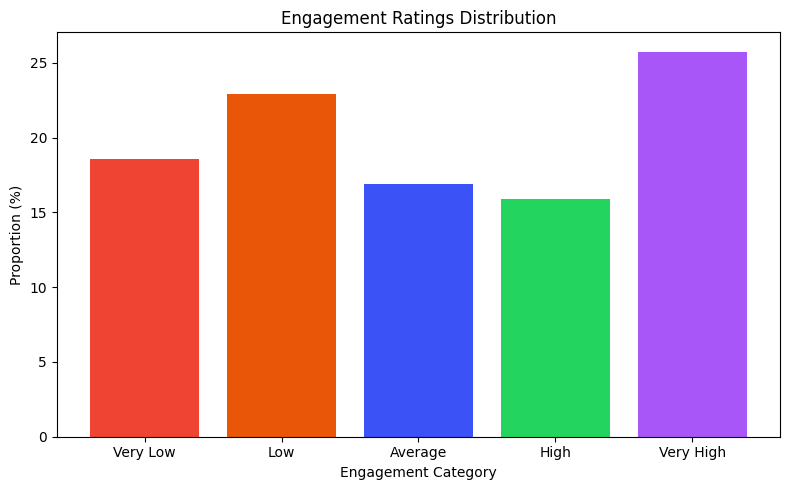

In [14]:
# Categorical view of engagement rate
youtube_videos['engagement_cat'] = pd.cut(
    youtube_videos['engagement_rate_raw'],
    bins=[0, 0.01, 0.025, 0.04, 0.06, float('inf')],
    labels=['Very Low', 'Low', 'Average', 'High', 'Very High'],
    right=False
)

cat_counts = youtube_videos['engagement_cat'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 5))
plt.bar(cat_counts.index, cat_counts.values,
        color=['#ef4434', '#ea5608', '#3a52f6', '#23d55e', '#a856f8'])
plt.title('Engagement Ratings Distribution')
plt.xlabel('Engagement Category')
plt.ylabel('Proportion (%)')
plt.tight_layout()
plt.show()

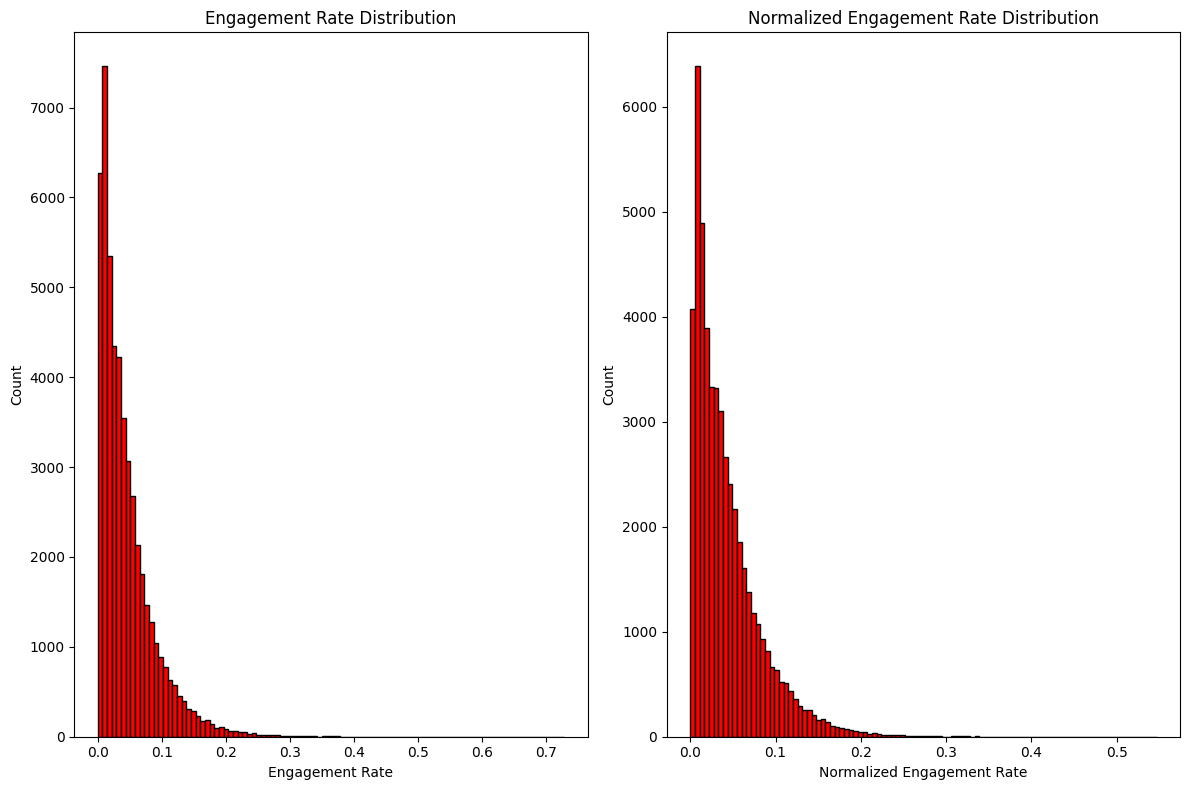

In [15]:
# Engagement Rate Distribution
fig, ax = plt.subplots(1,2,figsize=(12, 8))
ax[0].hist(youtube_videos['engagement_rate_raw'], bins=100, color='red', edgecolor='black')
ax[0].set_title("Engagement Rate Distribution")
ax[0].set_xlabel("Engagement Rate")
ax[0].set_ylabel("Count")


# Normalized Engagement Rate Distribution
ax[1].hist(youtube_videos['engagement_rate_log'], bins=100, color='red', edgecolor='black')
ax[1].set_title("Normalized Engagement Rate Distribution")
ax[1].set_xlabel("Normalized Engagement Rate")
ax[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

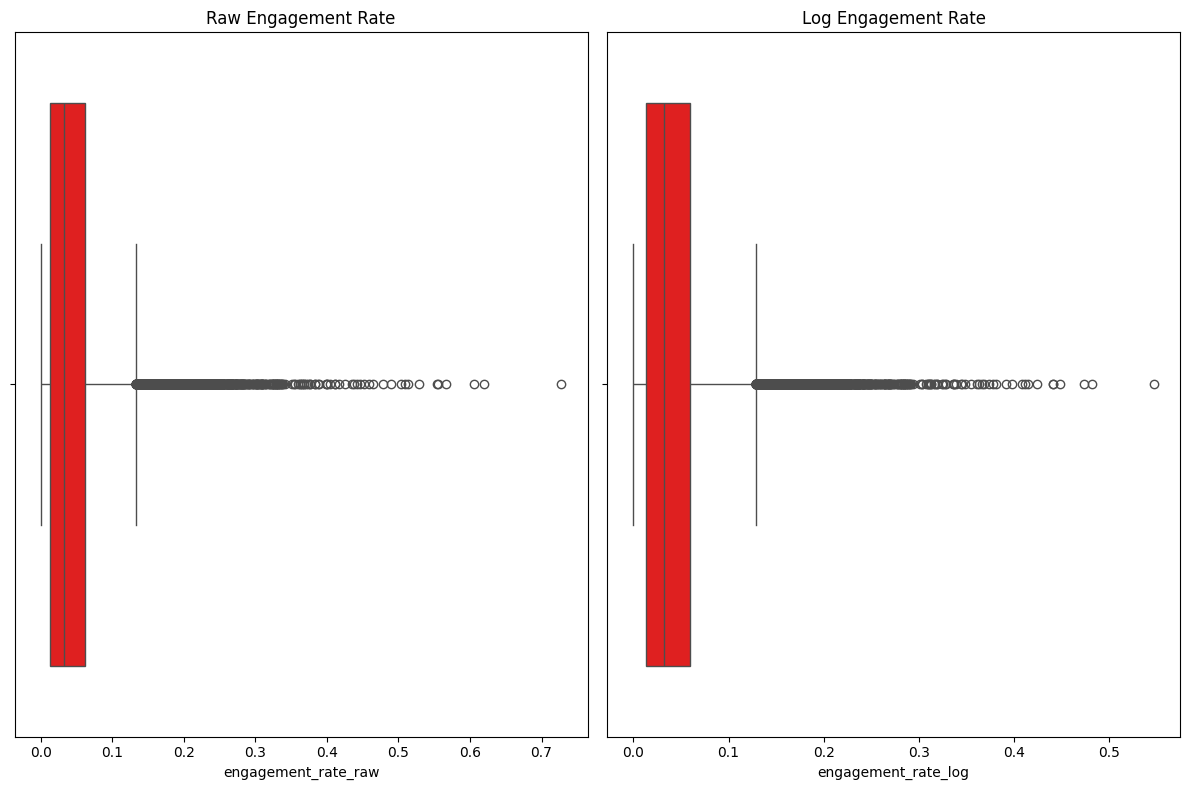


The log transform significantly normalises the right-skewed raw distribution.


In [16]:
# Boxplot of engagement rate
fig, ax = plt.subplots(1, 2, figsize=(12, 8))

# Raw engagement rate
sns.boxplot(x=youtube_videos['engagement_rate_raw'], ax=ax[0], color='red')
ax[0].set_title('Raw Engagement Rate')

# Log-transformed engagement rate
sns.boxplot(x=youtube_videos['engagement_rate_log'], ax=ax[1], color='red')
ax[1].set_title('Log Engagement Rate')

plt.tight_layout()
plt.show()

print("\nThe log transform significantly normalises the right-skewed raw distribution.")

In [17]:
# Clip some outliers
lower_bound = youtube_videos["engagement_rate_log"].quantile(0.01)
upper_bound = youtube_videos["engagement_rate_log"].quantile(0.99)

youtube_videos["engagement_rate_log_clipped"] = youtube_videos["engagement_rate_log"].clip(lower=lower_bound, upper=upper_bound)

/tmp/ipykernel_13639/2125311650.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = youtube_videos.groupby('view_bin')['engagement_rate_raw'].median()
/tmp/ipykernel_13639/2125311650.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = youtube_videos.groupby('view_bin')['views'].median()


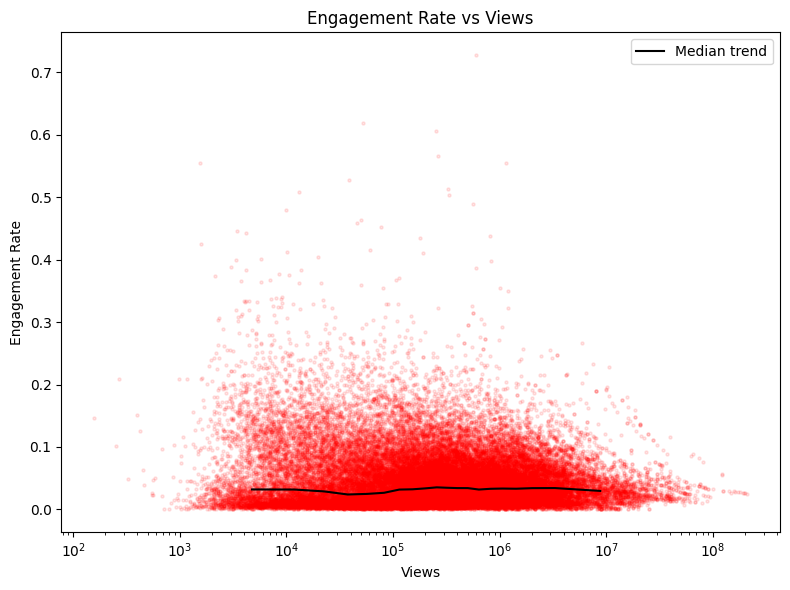

In [18]:
# Engagement vs Views
# Create quantile bins
youtube_videos['view_bin'] = pd.qcut(
    youtube_videos['views'],
    q=20,
    duplicates='drop'
)

# Compute median engagement
trend = youtube_videos.groupby('view_bin')['engagement_rate_raw'].median()
bin_centers = youtube_videos.groupby('view_bin')['views'].median()

# Plot original scatter
plt.figure(figsize=(8, 6))
plt.scatter(youtube_videos['views'], youtube_videos['engagement_rate_raw'],
            alpha=0.1, s=5, color='red')

# Trend line
plt.plot(bin_centers, trend.values, color='black', label='Median trend')

plt.xscale('log')
plt.xlabel("Views")
plt.ylabel("Engagement Rate")
plt.title("Engagement Rate vs Views")
plt.legend()
plt.tight_layout()
plt.show()

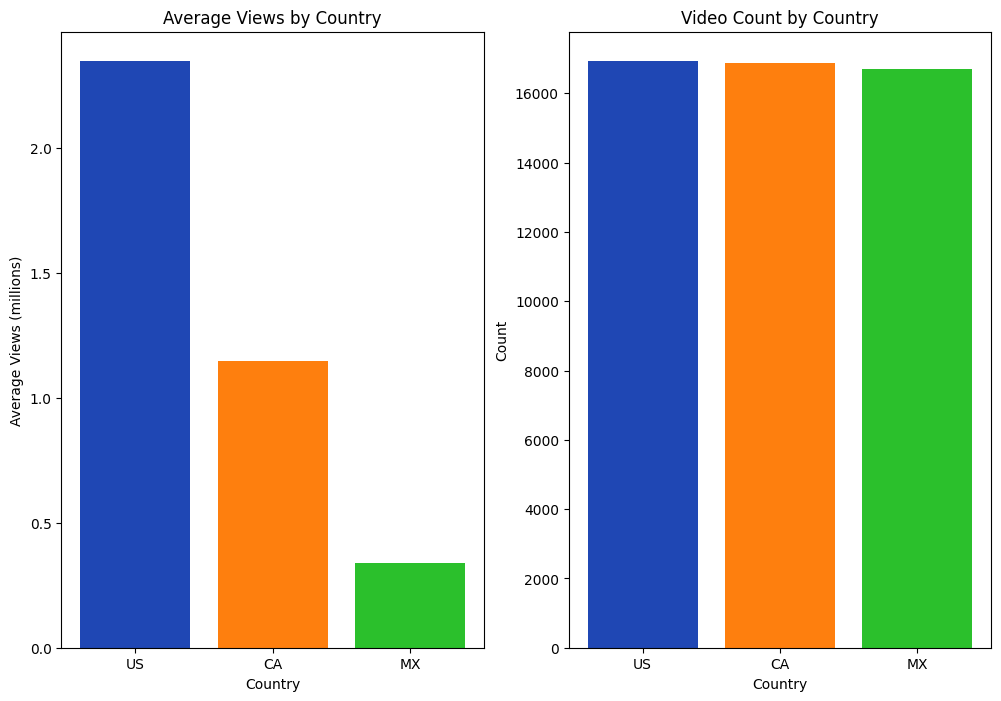

In [19]:
# Views by Country
fig, ax = plt.subplots(1, 2, figsize=(12, 8))

youtube_by_country = youtube_videos.groupby('country')['views'].mean().sort_values(ascending=False)
ax[0].bar(youtube_by_country.index, youtube_by_country.values / 1e6, color=['#1f47b4','#fe7f0e','#2bc02c'])
ax[0].set_title('Average Views by Country')
ax[0].set_xlabel('Country')
ax[0].set_ylabel('Average Views (millions)')

youtube_country_counts = youtube_videos['country'].value_counts()
ax[1].bar(youtube_country_counts.index, youtube_country_counts.values, color=['#1f47b4','#fe7f0e','#2bc02c'])
ax[1].set_title('Video Count by Country')
ax[1].set_xlabel('Country')
ax[1].set_ylabel('Count')

plt.show()

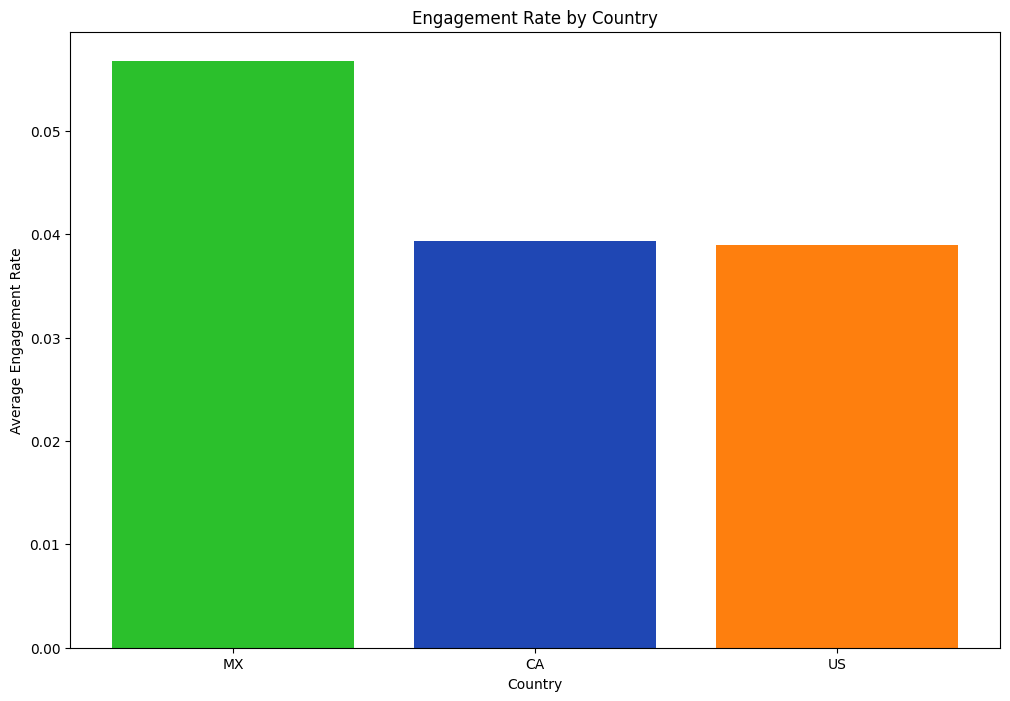

In [20]:
# Engagement Rate by Country
fig, ax = plt.subplots(figsize = (12, 8))

rate_by_country = youtube_videos.groupby('country')['engagement_rate_raw'].mean().sort_values(ascending=False)
ax.bar(rate_by_country.index, rate_by_country.values, color=['#2bc02c', '#1f47b4','#fe7f0e'])
ax.set_title('Engagement Rate by Country')
ax.set_xlabel('Country')
ax.set_ylabel('Average Engagement Rate')

plt.show()

## Feature Engineering

In [21]:
# Category Mapping
category_map = {
    1: "Film & Animation",
    2: "Autos & Vehicles",
    10: "Music",
    15: "Pets & Animals",
    17: "Sports",
    18: "Short Movies",
    19: "Travel & Events",
    20: "Gaming",
    21: "Videoblogging",
    22: "People & Blogs",
    23: "Comedy",
    24: "Entertainment",
    25: "News & Politics",
    26: "Howto & Style",
    27: "Education",
    28: "Science & Technology",
    29: "Nonprofits & Activism",
    30: "Movies",
    31: "Anime/Animation",
    32: "Action/Adventure",
    33: "Classics",
    35: "Documentary",
    36: "Drama",
    37: "Family",
    38: "Foreign",
    39: "Horror",
    40: "Sci-Fi/Fantasy",
    41: "Thriller",
    42: "Shorts",
    43: "Shows",
    44: "Trailers",
}

youtube_videos['category_name'] = youtube_videos['category_id'].apply(lambda x: category_map[x])

In [22]:
# Extract Post Hour
youtube_videos['publish_hour'] = youtube_videos.loc[:, 'publish_time'].dt.hour

# Extract Day of the Week
youtube_videos['publish_day'] = youtube_videos['publish_time'].dt.dayofweek
youtube_videos['publish_day_name'] = youtube_videos['publish_time'].dt.day_name()

In [23]:
# Determine Tag Count
youtube_videos['tag_count'] = youtube_videos['tags'].apply(lambda x: len(x))

# Determine Title Length
youtube_videos['title_length'] = youtube_videos['title'].apply(lambda x: len(x))

In [24]:
# Add Other Title Engagement Features
def extract_title_features(title):
    letters = [c for c in title if c.isalpha()]

    total_letters = len(letters)
    uppercase_letters = sum(1 for c in letters if c.isupper())

    caps_ratio = uppercase_letters / total_letters if total_letters > 0 else 0

    return {
        'title_has_question'   : int('?' in title),
        'title_has_exclamation': int('!' in title),
        'title_has_pipe'       : int('|' in title),
        'title_caps_ratio'     : caps_ratio,
        'title_has_number'     : int(any(c.isdigit() for c in title))
    }

title_features = youtube_videos['title'].apply(extract_title_features)
youtube_videos = pd.concat([youtube_videos, pd.DataFrame(title_features.to_list(), index=youtube_videos.index)], axis=1)

In [25]:

with open('sentiment_data.json', 'r') as sent_file:
    sentiment_df = pd.DataFrame(json.load(sent_file))

with open('desc_sentiment_data.json', 'r') as desc_file:
    desc_sentiment_df = pd.DataFrame(json.load(desc_file))


In [26]:
"""
# -------------------------------------------------------------------------
# AI USAGE CITATION
# Tool: Claude AI
# Prompt: "Write Python code that utilizes the Hugging Face API
# from torch to analyze the sentiment of a title using a multilingual model"
# Usage: Used the pipeline and GPU settings, but built the rest of the library calls and dataframe concatenation.

# Device setup
device = 0
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

# Initialize pipeline
text_pipeline = pipeline(
    'sentiment-analysis',
    model="cardiffnlp/twitter-roberta-base-sentiment",
    device=0,
    dtype=torch.float16,
    max_length=512
)

# Function to convert scores
def convert_full(res):
    label = res['label']
    score = res['score']
    return {
        'neg': score if label == 'LABEL_0' else 0.0,
        'neu': score if label == 'LABEL_1' else 0.0,
        'pos': score if label == 'LABEL_2' else 0.0
    }

# Reclean titles
titles = youtube_videos['title'].fillna('').astype(str).tolist()

# Run in batches
sentiment_data = []
results = text_pipeline(titles, truncation=True)
sentiment_data.extend([convert_full(r) for r in results])

# Convert to DataFrame columns
sentiment_df = pd.DataFrame(sentiment_data)
"""
# Attach to original dataframe
youtube_videos = youtube_videos.reset_index(drop=True)
youtube_videos[['title_neg', 'title_neu', 'title_pos']] = sentiment_df[['neg', 'neu', 'pos']].values
youtube_videos['title_sentiment'] = youtube_videos['title_pos'] - youtube_videos['title_neg']

In [27]:
"""
# Run sentiment pipeline on descriptions
descriptions = youtube_videos['description'].fillna('').astype(str).tolist()

desc_sentiment_data = []

desc_pipeline = pipeline(
    'sentiment-analysis',
    model="cardiffnlp/twitter-roberta-base-sentiment",
    device=0,
    dtype=torch.float32,
    max_length=512
)

for i in range(0, len(descriptions), 64):
    batch = descriptions[i:i+64]
    results = desc_pipeline(batch, truncation=True)
    desc_sentiment_data.extend([convert_full(r) for r in results])

desc_sentiment_df = pd.DataFrame(desc_sentiment_data)
"""
youtube_videos[['description_neg', 'description_neu', 'description_pos']] = desc_sentiment_df[['neg', 'neu', 'pos']].values
youtube_videos['description_sentiment'] = youtube_videos['description_pos'] - youtube_videos['description_neg']

In [28]:
print("\nTitle sentiment summary:")
print(youtube_videos['title_sentiment'].describe().round(4))
print("\nDescription sentiment summary:")
print(youtube_videos['description_sentiment'].describe().round(4))


Title sentiment summary:
count    50531.0000
mean        -0.0044
std          0.2543
min         -0.9803
25%          0.0000
50%          0.0000
75%          0.0000
max          0.9914
Name: title_sentiment, dtype: float64

Description sentiment summary:
count    50531.0000
mean         0.1357
std          0.3373
min         -0.9790
25%          0.0000
50%          0.0000
75%          0.0000
max          0.9935
Name: description_sentiment, dtype: float64


In [29]:
"""
# Dump title stats into json file for reusability
with open('sentiment_data.json', 'w') as f:
    json.dump(sentiment_data, f)

# Dump description stats into json file for reusability
with open('desc_sentiment_data.json', 'w') as f:
    json.dump(desc_sentiment_data, f)
"""

"\n# Dump title stats into json file for reusability\nwith open('sentiment_data.json', 'w') as f:\n    json.dump(sentiment_data, f)\n\n# Dump description stats into json file for reusability\nwith open('desc_sentiment_data.json', 'w') as f:\n    json.dump(desc_sentiment_data, f)\n"

## Final Exploratory Data Analysis

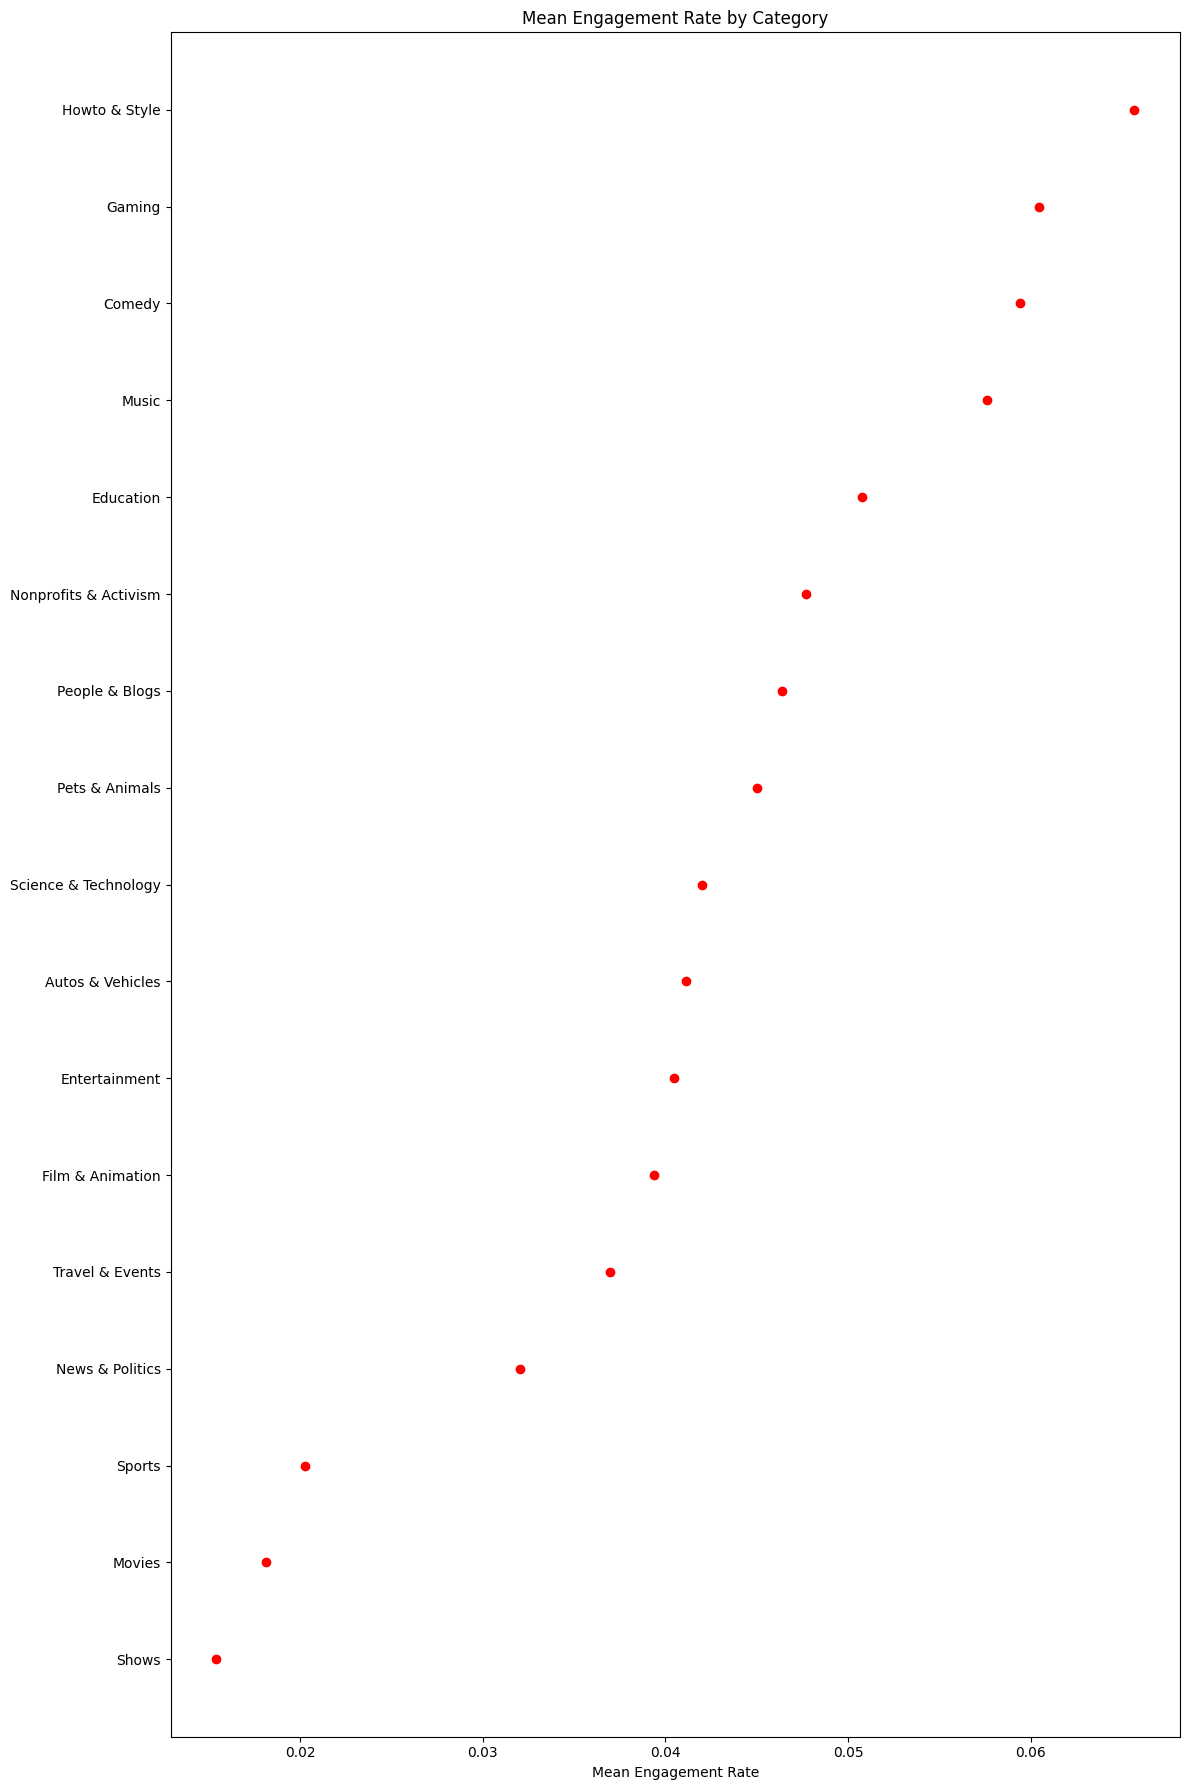

In [30]:
# Engagement Rate by Category Name
engagement_by_category = youtube_videos.groupby('category_name')['engagement_rate_raw'].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 18))
plt.plot(engagement_by_category.values, engagement_by_category.index, 'o', color='red')
plt.title('Mean Engagement Rate by Category')
plt.xlabel('Mean Engagement Rate')
plt.tight_layout()
plt.show()

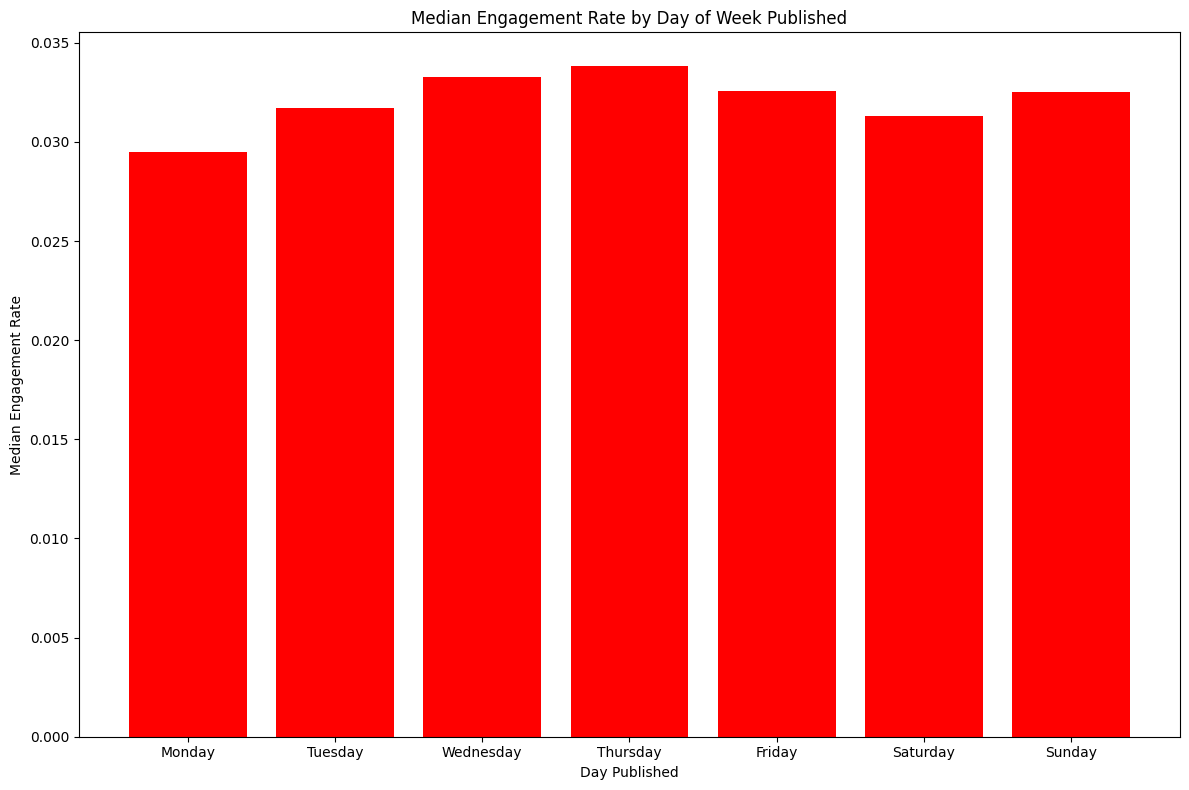

In [31]:
# Engagement Rate by Publish Day Name
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
engagement_by_day = (youtube_videos.groupby('publish_day_name')['engagement_rate_raw']
           .median().reindex(day_order))

plt.figure(figsize=(12, 8))
plt.bar(engagement_by_day.index, engagement_by_day.values, color='red')
plt.title('Median Engagement Rate by Day of Week Published')
plt.xlabel('Day Published')
plt.ylabel('Median Engagement Rate')
plt.tight_layout()
plt.show()

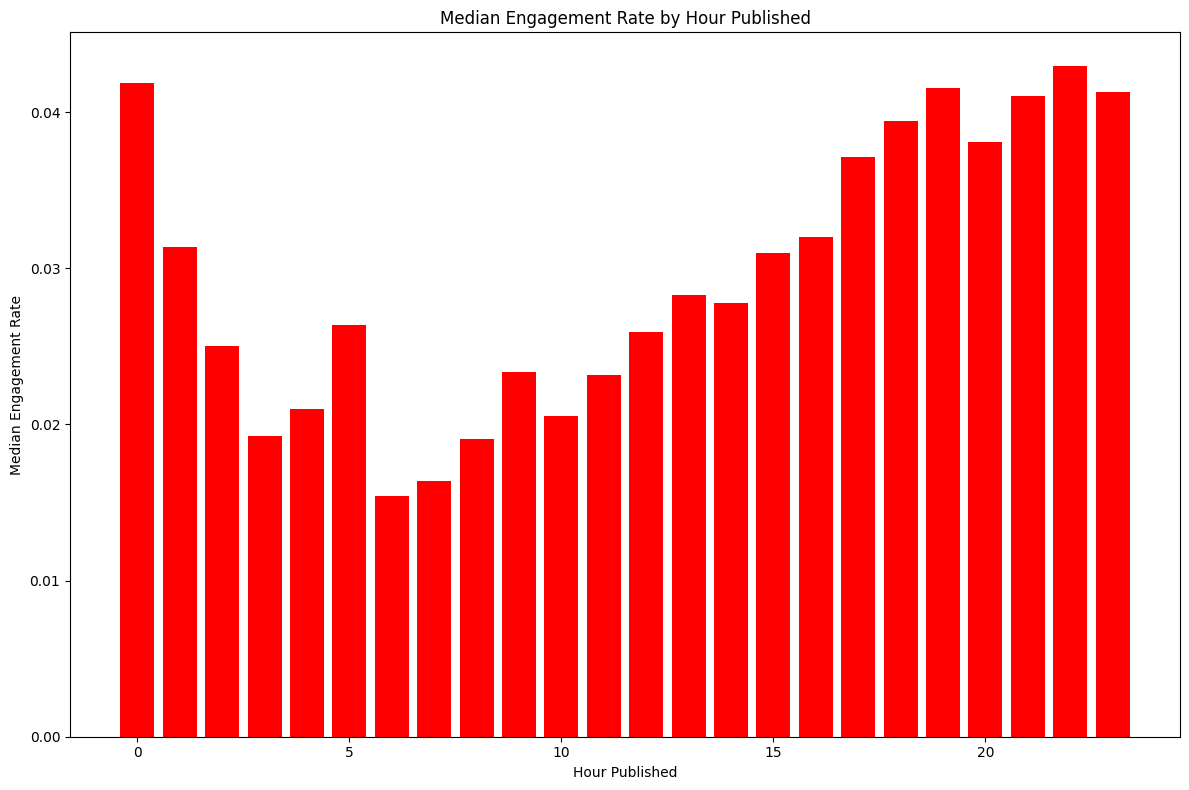

In [32]:
# Engagement Rate by Publish Hour
engagement_by_hour = youtube_videos.groupby('publish_hour')['engagement_rate_raw'].median().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
plt.bar(engagement_by_hour.index, engagement_by_hour.values, color='red')
plt.title('Median Engagement Rate by Hour Published')
plt.xlabel('Hour Published')
plt.ylabel('Median Engagement Rate')
plt.tight_layout()
plt.show()

We see that the lowest engagement hours are between the early hour mornings. This will be important for our UI.

/tmp/ipykernel_13639/312265970.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = youtube_videos.groupby('title_bin')['engagement_rate_raw'].median()
/tmp/ipykernel_13639/312265970.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = youtube_videos.groupby('title_bin')['title_length'].median()


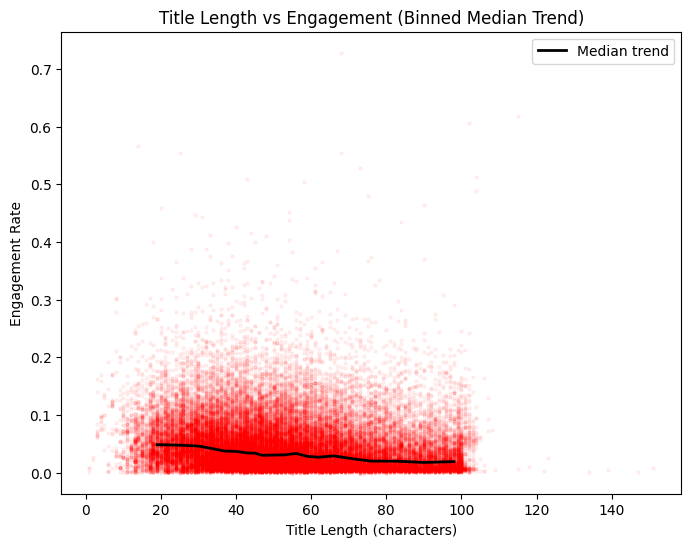

In [33]:
# Title Length vs Engagement Rate
# Bin title length
youtube_videos['title_bin'] = pd.qcut(
    youtube_videos['title_length'],
    q=20,
    duplicates='drop'
)

# Compute median engagement
trend = youtube_videos.groupby('title_bin')['engagement_rate_raw'].median()
bin_centers = youtube_videos.groupby('title_bin')['title_length'].median()

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(youtube_videos['title_length'], youtube_videos['engagement_rate_raw'],
            alpha=0.05, s=5, color='red')

plt.plot(bin_centers, trend.values, color='black', linewidth=2, label='Median trend')

plt.xlabel("Title Length (characters)")
plt.ylabel("Engagement Rate")
plt.title("Title Length vs Engagement (Binned Median Trend)")
plt.legend()

plt.show()

/tmp/ipykernel_13639/192454021.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = youtube_videos.groupby('sentiment_bin')['title_sentiment'].median()
/tmp/ipykernel_13639/192454021.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


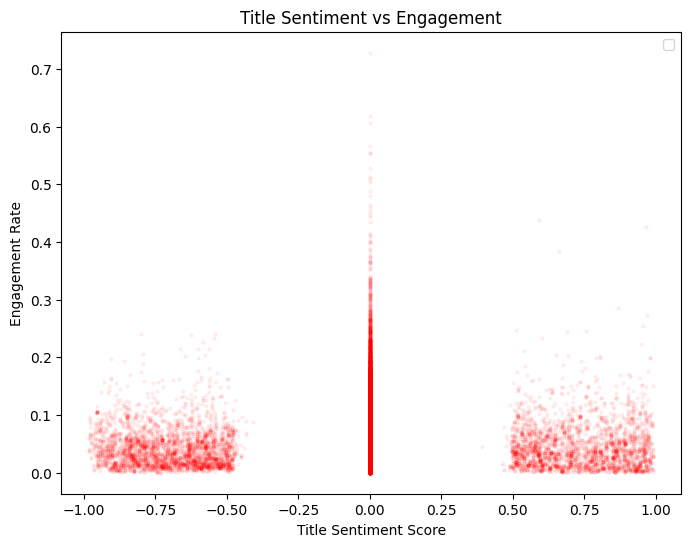

In [34]:
# Correlation between Title Sentiment and Engagement
# Define fixed sentiment bins
bins = np.linspace(-1, 1, 21)
youtube_videos['sentiment_bin'] = pd.cut(youtube_videos['title_sentiment'], bins=bins)

# Compute median engagement
bin_centers = youtube_videos.groupby('sentiment_bin')['title_sentiment'].median()

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(youtube_videos['title_sentiment'], youtube_videos['engagement_rate_raw'],
            alpha=0.05, s=5, color='red')


plt.xlabel("Title Sentiment Score")
plt.ylabel("Engagement Rate")
plt.title("Title Sentiment vs Engagement")
plt.legend()

plt.show()

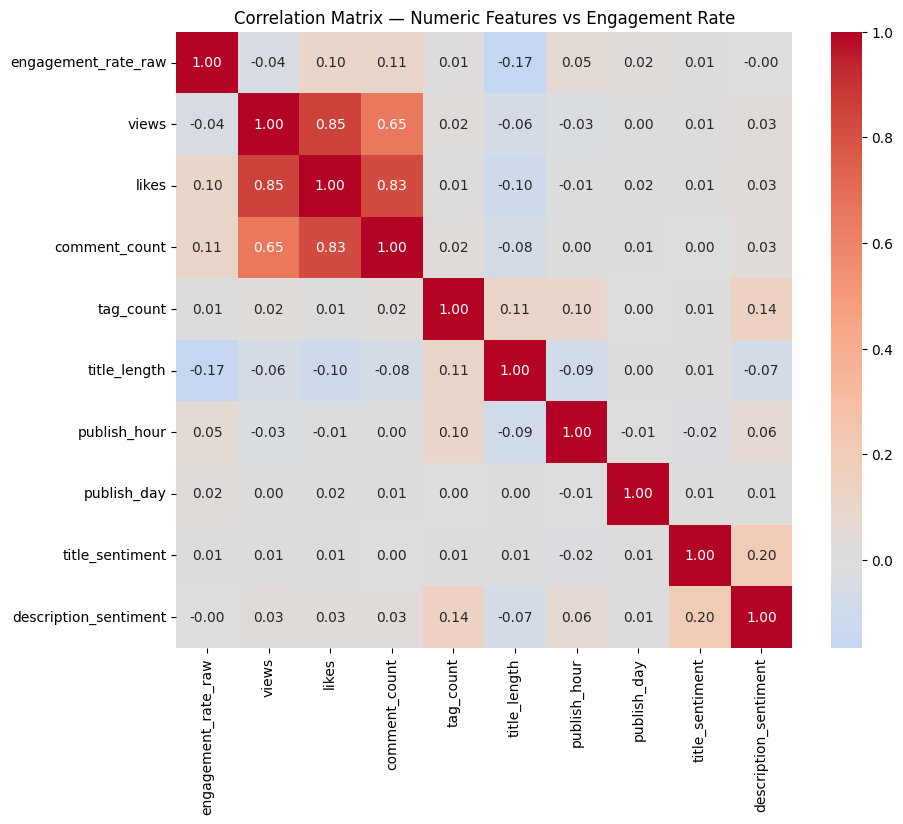

Top correlations with engagement_rate_raw:
title_length            -0.1665
comment_count            0.1124
likes                    0.1039
publish_hour             0.0529
views                   -0.0420
publish_day              0.0235
tag_count                0.0140
title_sentiment          0.0121
description_sentiment   -0.0002


In [35]:
# General Correlation Matrix
corr_cols = ['engagement_rate_raw', 'views', 'likes', 'comment_count',
             'tag_count', 'title_length', 'publish_hour', 'publish_day',
             'title_sentiment', 'description_sentiment']
corr_matrix = youtube_videos[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True)
plt.title('Correlation Matrix — Numeric Features vs Engagement Rate')
plt.show()

eng_corr = corr_matrix['engagement_rate_raw'].drop('engagement_rate_raw').sort_values(key=abs, ascending=False)
print("Top correlations with engagement_rate_raw:")
print(eng_corr.round(4).head(10).to_string())

## Model Preparation

In [36]:
# Select features to use
features = [
    'category_id',
    'comments_disabled',
    'publish_hour',
    'publish_day',
    'tag_count',
    'title_length',
    'title_sentiment',
    'description_sentiment',
    'country',
    'title_has_question',
    'title_has_exclamation',
    'title_has_pipe',
    'title_caps_ratio',
    'title_has_number'
]

In [37]:
# Separate Features from Labels
X = youtube_videos[features]
y = youtube_videos["engagement_rate_log_clipped"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [38]:
# Selected the following numeric columns
numeric_columns = ['title_sentiment',
                   'description_sentiment',
                   'tag_count',
                   'title_length',
                   'title_has_question',
                   'title_has_exclamation',
                   'title_has_pipe',
                   'title_caps_ratio',
                   'title_has_number']

# Selected the following categorical columns
categorical_columns = ['category_id', 'comments_disabled', 'publish_hour', 'publish_day', 'country']

In [39]:
# Creates numeric pipeline
# Scales the data to reduce dimensionality
numeric_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

# Creates categorical pipeline
# One Hot Encodes Categorical Features
categorical_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
)

# Uses ColumnTransformers to pass the data through the different pipelines to handle the variety of data types
column_transformer = ColumnTransformer(
    [('num', numeric_pipeline, numeric_columns),
     ('cat', categorical_pipeline, categorical_columns)]
)

# Fit and transform the data through the ColumnTransformers
X_train_transformed = column_transformer.fit_transform(X_train)
X_test_transformed = column_transformer.transform(X_test)

## Model Creation

In [40]:
# Create Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train_transformed, y_train)

LinearRegression()

In [42]:
# RandomizedSearchCV for Random Forest Regression
rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 20],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt'],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
rf_search.fit(X_train_transformed, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV R²: ", rf_search.best_score_.round(4))

best_rf_model = rf_search.best_estimator_

# RandomizedSearchCV for XGBoost
xgb_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(tree_method='hist'),
    param_distributions=xgb_param_grid,
    n_iter=30,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
xgb_search.fit(X_train_transformed, y_train)

print("Best params:", xgb_search.best_params_)
print("Best CV R²: ", xgb_search.best_score_.round(4))

best_xgb_model = xgb_search.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV R²:  0.4891
Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'subsample': 0.8, 'reg_alpha': 0.1, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV R²:  0.4246


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.2375 - mae: 0.3469 - val_loss: 0.0094 - val_mae: 0.0774
Epoch 2/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0512 - mae: 0.1714 - val_loss: 0.0063 - val_mae: 0.0621
Epoch 3/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0233 - mae: 0.1149 - val_loss: 0.0044 - val_mae: 0.0505
Epoch 4/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0131 - mae: 0.0856 - val_loss: 0.0031 - val_mae: 0.0421
Epoch 5/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0084 - mae: 0.0680 - val_loss: 0.0024 - val_mae: 0.0363
Epoch 6/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0061 - mae: 0.0572 - val_loss: 0.0020 - val_mae: 0.0338
Epoch 7/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - mae: 0.0501 - val_loss: 0.0018 - val_mae: 0.0312
Epoch 8/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0037 - mae: 0.0449 - val_loss: 0.0017 - val_mae: 0.0309
Epoch 9/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms

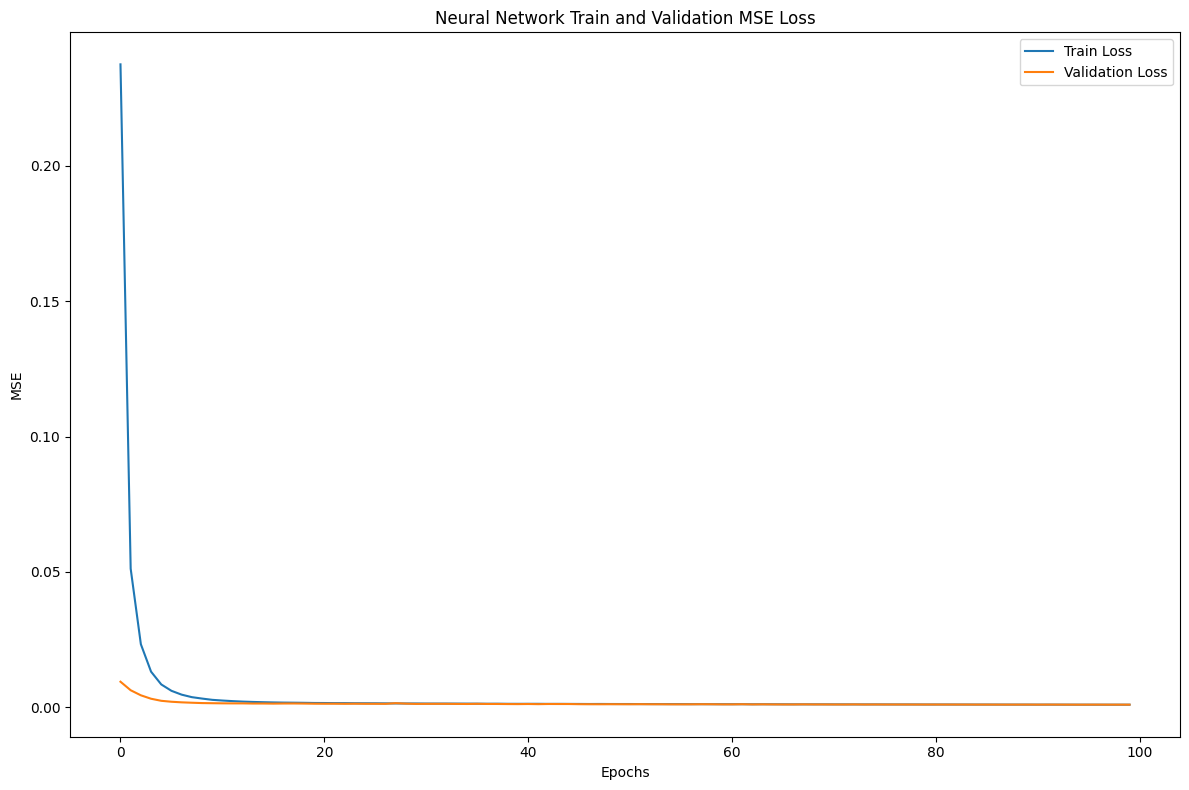

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,917 (214.52 KB)

 Trainable params: 18,177 (71.00 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 36,356 (142.02 KB)

In [43]:
# Create neural network
input_dim = X_train_transformed.shape[1]

nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

nn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

hist = nn_model.fit(
    X_train_transformed, y_train,
    validation_data=(X_test_transformed, y_test),
    batch_size=256,
    epochs=100,
    verbose=1
)

plt.figure(figsize=(12,8))
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.title("Neural Network Train and Validation MSE Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

nn_model.summary()


Training: batch_size=64, lr=0.01, dropout=0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Min val_loss: 0.0009

Training: batch_size=64, lr=0.01, dropout=0.2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Min val_loss: 0.0009

Training: batch_size=64, lr=0.001, dropout=0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Min val_loss: 0.0009

Training: batch_size=64, lr=0.001, dropout=0.2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Min val_loss: 0.0009

Best config:
batch_size=64, lr=0.01, dropout=0.2
Best val_loss=0.0009


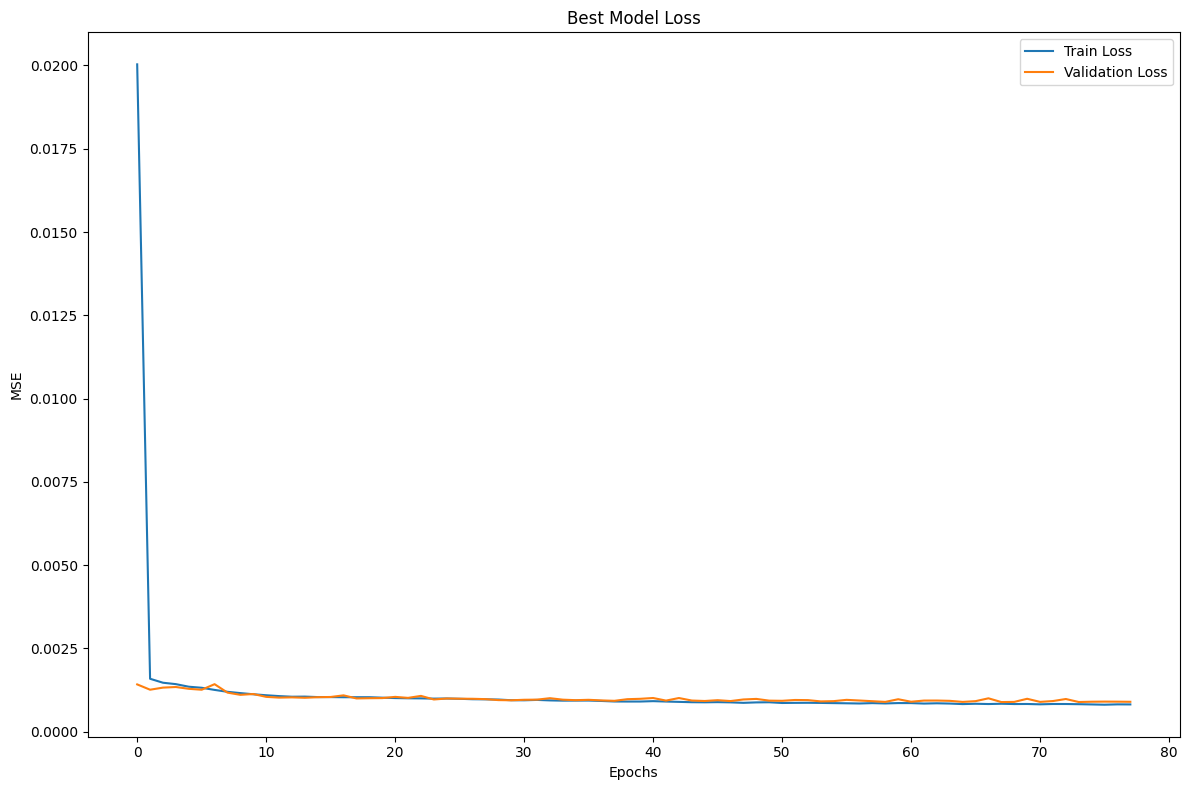

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,173 (215.52 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 36,484 (142.52 KB)

In [45]:

# Hyperparameter Tuning
batch_sizes = [64]
learning_rates = [1e-2, 1e-3]
dropouts = [0.1, 0.2]

best_val_loss = float('inf')
best_model = None
best_config = None
best_history = None

for batch_size in batch_sizes:
    for lr in learning_rates:
        for dr in dropouts:
            print(f"\nTraining: batch_size={batch_size}, lr={lr}, dropout={dr}")

            # Build model
            model = Sequential([
                Dense(128, activation='relu', input_shape=(input_dim,)),
                BatchNormalization(),
                Dropout(dr),

                Dense(64, activation='relu'),
                BatchNormalization(),
                Dropout(dr),

                Dense(32, activation='relu'),
                BatchNormalization(),

                Dense(1, activation='linear')
            ])

            optimizer = Adam(learning_rate=lr)

            model.compile(
                optimizer=optimizer,
                loss='mse',
                metrics=['mae']
            )

            # Callbacks
            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                verbose=0
            )

            # Train
            history = model.fit(
                X_train_transformed, y_train,
                validation_data=(X_test_transformed, y_test),
                batch_size=batch_size,
                epochs=100,
                callbacks=[early_stop],
                verbose=0
            )

            # Evaluate
            min_val_loss = np.min(history.history['val_loss'])
            print(f"Min val_loss: {min_val_loss:.4f}")

            # Track best metrics
            if min_val_loss < best_val_loss:
                best_val_loss = min_val_loss
                best_nn_model = model
                best_config = (batch_size, lr, dr)
                best_history = history

print("\nBest config:")
print(f"batch_size={best_config[0]}, lr={best_config[1]}, dropout={best_config[2]}")
print(f"Best val_loss={best_val_loss:.4f}")

# Plot best model performance
plt.figure(figsize=(12,8))
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title("Best Model Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

# Summary of best model
best_nn_model.summary()


## Model Evaluation

In [54]:
# Collect results from all four models
models = {
    'Random Forest': best_rf_model,
    'XGBoost': best_xgb_model,
    'Linear Regression': linear_model,
    'Neural Network': best_nn_model,
}

print(f"{'Model':<25} {'R² (raw)':>10} {'MAE (raw)':>12} {'RMSE (raw)':>12}")
print("-" * 68)

for name, model in models.items():
    # Suppress verbose output for Neural Network predict method
    if name == 'Neural Network':
        y_pred_log = model.predict(X_test_transformed, verbose=0)
    else:
        y_pred_log = model.predict(X_test_transformed)

    # Ensure y_pred_log is flattened only if it's a Neural Network
    if name == 'Neural Network' and y_pred_log.ndim > 1:
        y_pred_log = y_pred_log.flatten()

    y_pred_raw = np.expm1(y_pred_log)
    y_test_raw = np.expm1(y_test)

    # Calculate metrics
    r2_raw   = r2_score(y_test, y_pred_log)
    mae_raw  = mean_absolute_error(y_test, y_pred_log)
    rmse_raw = root_mean_squared_error(y_test, y_pred_log)

    print(f"{name:<24} {r2_raw:>10.4f} {mae_raw:>12.4f} {rmse_raw:>12.4f}")

Model                       R² (raw)    MAE (raw)   RMSE (raw)
--------------------------------------------------------------------
Random Forest                0.5194       0.0163       0.0267
XGBoost                      0.4426       0.0193       0.0288
Linear Regression            0.2459       0.0246       0.0335
Neural Network               0.4015       0.0204       0.0298


/tmp/ipykernel_13639/1945632009.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_pred_log.max()],


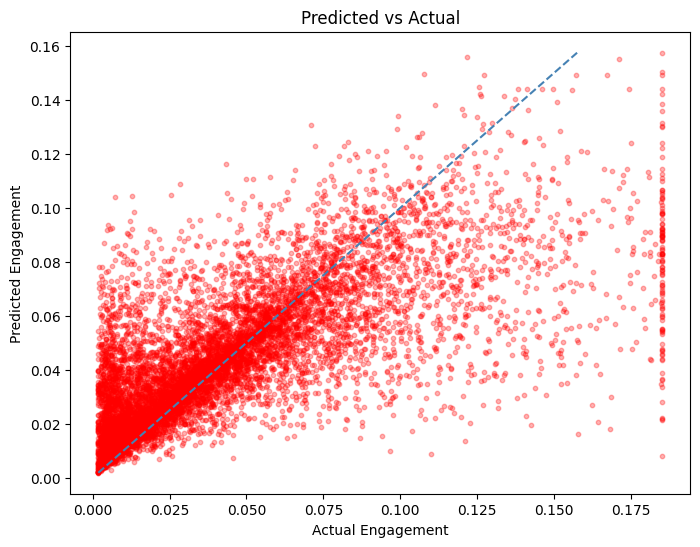

In [60]:
# Predicted vs Actual
# Get predictions from the best model
best_model = best_rf_model
y_pred_log = best_model.predict(X_test_transformed)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_log, alpha=0.3, s=10, color='red')
plt.plot([y_test.min(), y_pred_log.max()],
         [y_test.min(), y_pred_log.max()],
         'r--', color='steelblue')
plt.xlabel("Actual Engagement")
plt.ylabel("Predicted Engagement")
plt.title("Predicted vs Actual")
plt.show()

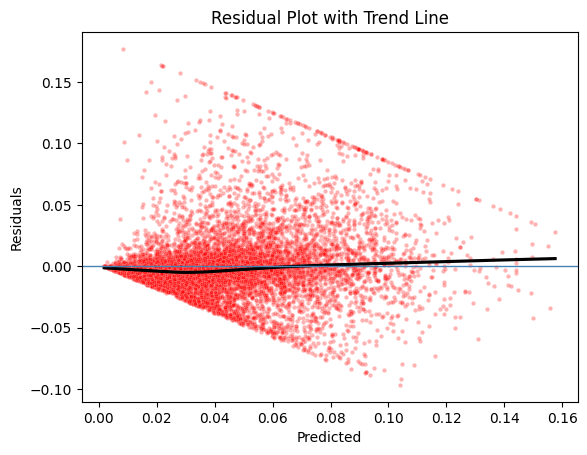

In [64]:
# Residual plot for the best model
residuals = y_test - y_pred_log

sns.scatterplot(x=y_pred_log, y=residuals, alpha=0.3, s=10, color='red')
sns.regplot(x=y_pred_log, y=residuals, scatter=False, lowess=True, color='black')

plt.axhline(0, color='steelblue', linewidth=1)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot with Trend Line")

plt.show()

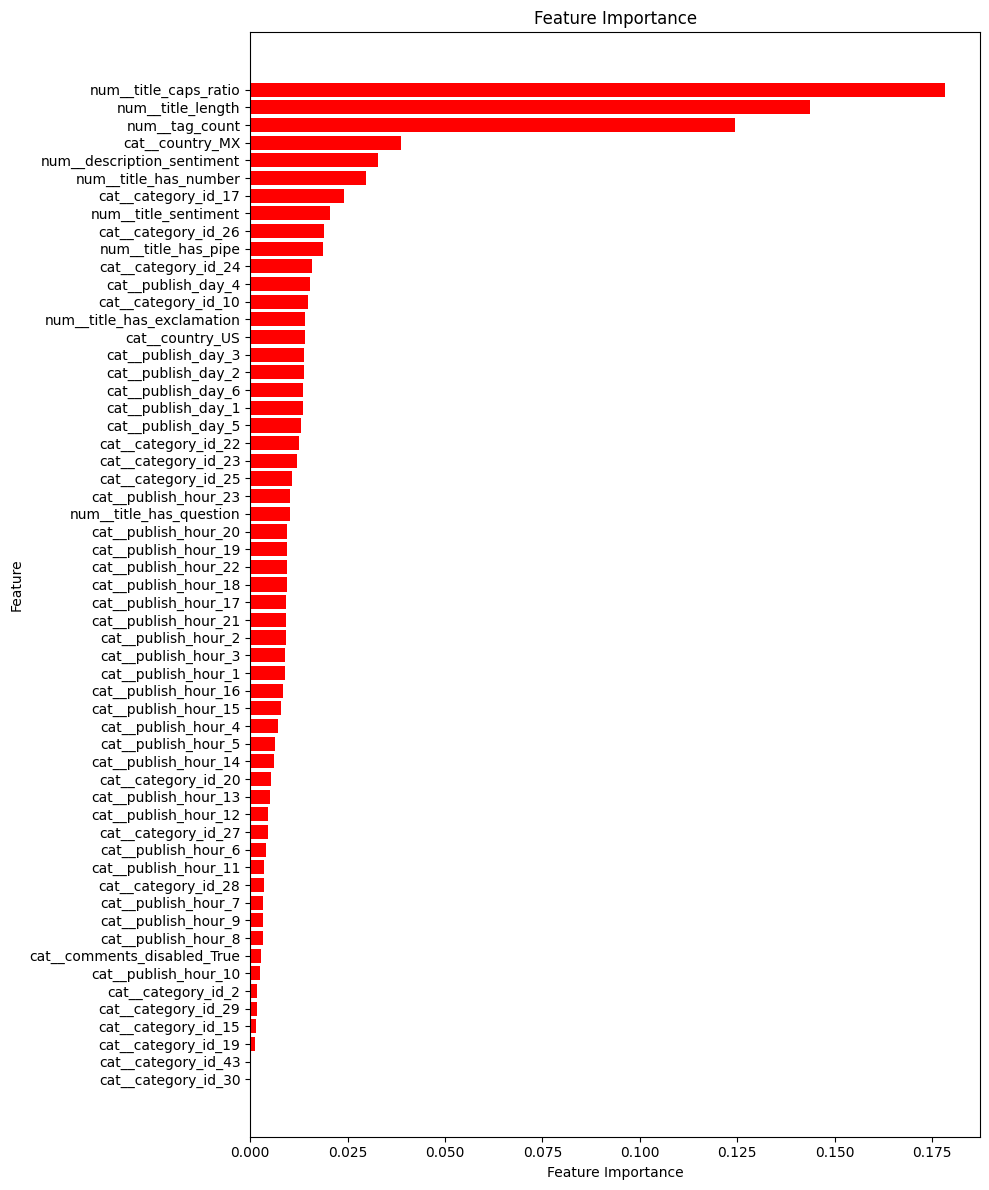

In [65]:
# View Feature Importances
feature_importance = best_model.feature_importances_
features = column_transformer.get_feature_names_out()

# Sort indices by importance in descending order
sorted_idx = np.argsort(feature_importance)

sorted_importances = feature_importance[sorted_idx]
sorted_features = features[sorted_idx]

# Plot
plt.figure(figsize=(10, 12))
plt.barh(sorted_features, sorted_importances, color='red')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## Model Utilization and Prep for UI

In [66]:
# Engagement stats
y_train_raw = np.expm1(y_train)

engagement_stats = {
    'mean'       : float(y_train_raw.mean()),
    'std'        : float(y_train_raw.std()),
    'p1'         : float(np.percentile(y_train_raw, 1)),
    'p99'        : float(np.percentile(y_train_raw, 99)),
    'percentiles': np.percentile(y_train_raw, np.arange(0, 101)).tolist(),
}


# Load best model, transformer, and engagement stats for future use
with open('youtube_model.pkl', 'wb') as f:
    pkl.dump(best_model, f)

with open('column_transformer.pkl', 'wb') as f:
    pkl.dump(column_transformer, f)

# Engagement stats
with open('engagement_stats.pkl', 'wb') as f:
    pkl.dump(engagement_stats, f)

# Category stats
with open("category_stats.pkl", "wb") as f:
    pkl.dump(engagement_by_category, f)

print("Successfully saved all models and tools for UI")

Successfully saved all models and tools for UI
